In [42]:
import os
# import globautoriaNumberplateOcrRu-2021-09-01
import easyocr
import math
import random
import json
import glob

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import cv2
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATASET_ROOT = r"C:\python\try_to_nn\CV_ITMO\sem_1\autoriaNumberplateOcrRu"

BATCH_SIZE = 32
IMG_HEIGHT = 32
IMG_WIDTH = 128
MAX_EPOCHS = 40
NUM_WORKERS = 0
RANDOM_SEED = 42

MAX_TRAIN_SAMPLES = 3000
MAX_TEST_SAMPLES = 300

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [2]:
ALPHABET = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
blank_idx = 0
char2idx = {c: i + 1 for i, c in enumerate(ALPHABET)}
idx2char = {i + 1: c for i, c in enumerate(ALPHABET)}
vocab_size = len(ALPHABET) + 1

train_transforms = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((IMG_HEIGHT, IMG_WIDTH)),
    T.ToTensor(),
    T.Normalize((0.5,), (0.5,))
])

test_transforms = train_transforms

class NumberplateOCRDataset(Dataset):
    def __init__(self, root, split, transforms=None, max_samples=None):
        self.root = root
        self.split = split
        self.transforms = transforms
        ann_dir = os.path.join(root, split, "ann")
        self.ann_paths = glob.glob(os.path.join(ann_dir, "*.json"))
        self.ann_paths.sort()
        if max_samples is not None:
            self.ann_paths = self.ann_paths[:max_samples]

    def __len__(self):
        return len(self.ann_paths)

    def encode_text(self, text):
        return [char2idx[c] for c in str(text) if c in char2idx]

    def __getitem__(self, idx):
        ann_path = self.ann_paths[idx]
        with open(ann_path, "r", encoding="utf-8") as f:
            data = json.load(f)
        name = data["name"]
        text = str(data.get("description", ""))
        img_rel = os.path.join(self.split, "img", name + ".png")
        img_path = os.path.join(self.root, img_rel)
        image = Image.open(img_path).convert("RGB")
        if self.transforms is not None:
            image = self.transforms(image)
        label = torch.tensor(self.encode_text(text), dtype=torch.long)
        return image, label, text

train_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "train", transforms=train_transforms, max_samples=MAX_TRAIN_SAMPLES
)
test_dataset = NumberplateOCRDataset(
    DATASET_ROOT, "test", transforms=test_transforms, max_samples=MAX_TEST_SAMPLES
)

def collate_fn(batch):
    batch = [b for b in batch if len(b[1]) > 0]
    images = [b[0] for b in batch]
    labels = [b[1] for b in batch]
    texts = [b[2] for b in batch]
    images = torch.stack(images, dim=0)
    label_lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    targets = torch.cat(labels, dim=0)
    return images, targets, label_lengths, texts

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
    drop_last=False
)

In [25]:
from ultralytics import YOLO

model_path = r"C:\python\try_to_nn\CV_ITMO\sem_1\data_car_number_labels\runs\detect\car_number_1003263\weights\best.pt"
# model_path = r"C:\python\try_to_nn\CV_ITMO\yolo26n.pt"
model = YOLO(model_path)
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

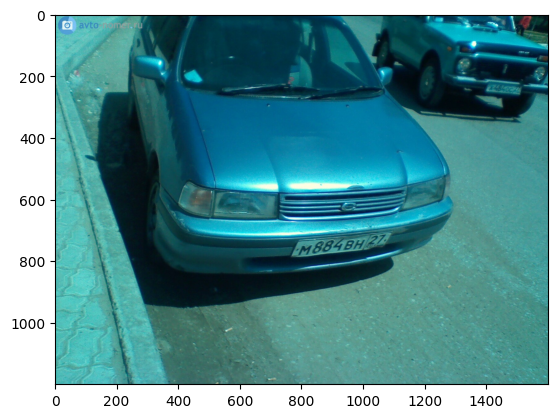

In [26]:
auto_img_path = r"C:\python\try_to_nn\CV_ITMO\sem_1\data_car_number_labels\images\train\20.jpg"
image_test_car = cv2.imread(auto_img_path)
image_test_car = cv2.cvtColor(image_test_car, cv2.COLOR_BGR2RGB)
plt.imshow(image_test_car)
# plt.imshow(image_test_car[:, :, ::-1])



0: 480x640 2 cars, 79.0ms
Speed: 7.0ms preprocess, 79.0ms inference, 2.4ms postprocess per image at shape (1, 3, 480, 640)
1024 0 1600 337


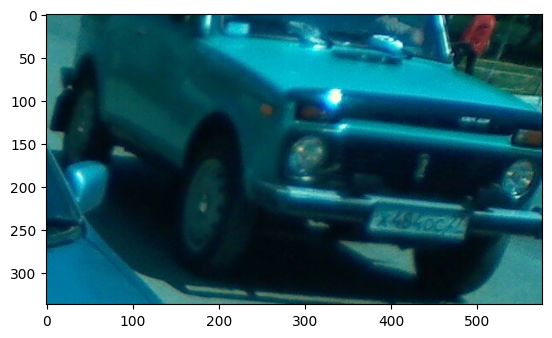

179 0 1295 851


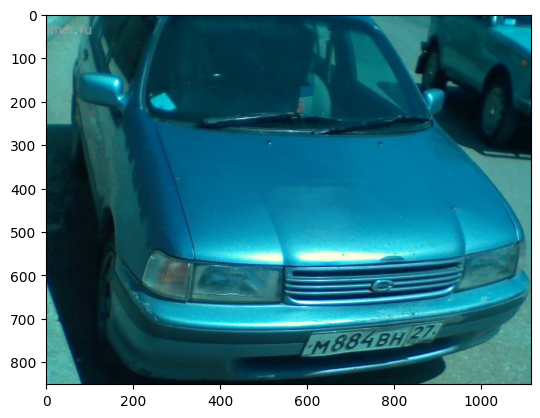

In [31]:
results = model(image_test_car)
results[0]


boxes = results[0].boxes
for idx, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    x1, y1, x2, y2 = max(0, x1), max(0, y1), min(image_test_car.shape[1], x2), min(image_test_car.shape[0], y2)
    print(x1, y1, x2, y2)
    crop = image_test_car[y1:y2, x1:x2]
    plt.imshow(crop)
    plt.show()

tensor([11,  1,  9,  9, 21, 21,  7,  1])


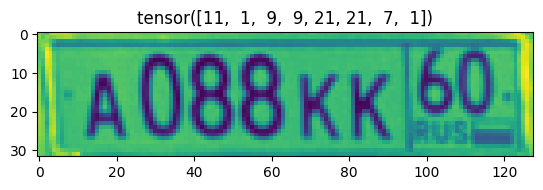

In [37]:
image, label, text = train_dataset[0]

print(label)
plt.title(label)
plt.imshow(image[0, :, :])
plt.show()

In [44]:
class CNNBackbone(nn.Module):
    def __init__(self, in_ch=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 2), (2, 1), (0, 1)),

            nn.Conv2d(256, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d((2, 2), (2, 1), (0, 1))
        )

    def forward(self, x):
        return self.net(x)


class CRNN(nn.Module):
    def __init__(self, img_h, num_channels, num_classes, hidden_size=256, num_layers=2):
        super().__init__()
        self.backbone = CNNBackbone(num_channels)
        self.pool = nn.AdaptiveAvgPool2d((1, None))
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.LSTM(
            input_size=256,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=False
        )
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        x = self.pool(feat)
        b, c, h, w = x.size()
        x = x.view(b, c, w)
        x = x.permute(2, 0, 1)
        x, _ = self.rnn(x)
        x = self.fc(x)
        x = x.log_softmax(2)
        return x

model = CRNN(IMG_HEIGHT, 1, vocab_size).to(device)
criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [45]:
# optimizer = torch.optim.Adam(model.parameters())
# criterion = torch.nn.CrossEntropyLoss()

def decode_sequence(seq):
    seq = seq.cpu().numpy().tolist()
    prev = None
    out = []
    for s in seq:
        if s != blank_idx and s != prev:
            if s in idx2char:
                out.append(idx2char[s])
        prev = s
    return "".join(out)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, targets, target_lengths, _ in loader:
        images = images.to(device)
        targets = targets.to(device)
        target_lengths = target_lengths.to(device)
        logits = model(images)
        T_cur, N_cur, C_cur = logits.size()
        input_lengths = torch.full(
            size=(N_cur,), fill_value=T_cur, dtype=torch.long, device=logits.device
        )
        loss = criterion(logits, targets, input_lengths, target_lengths)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        running_loss += loss.item()
    return running_loss / max(1, len(loader))

def evaluate(model, loader, max_batches=3):
    model.eval()
    samples = []
    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            pred = logits.permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = texts[i]
                samples.append((gt, decoded))
            if bi + 1 >= max_batches:
                break
    return samples

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    print(f"Epoch {epoch}/{MAX_EPOCHS}, train loss: {train_loss:.4f}")

test_samples = evaluate(model, test_loader, max_batches=2)
for i, (gt, pred) in enumerate(test_samples[:20]):
    print(f"{i+1}. GT: {gt} | PRED: {pred}")

Epoch 1/40, train loss: 3.0273
Epoch 2/40, train loss: 2.2163
Epoch 3/40, train loss: 2.0399
Epoch 4/40, train loss: 1.9537
Epoch 5/40, train loss: 1.7385
Epoch 6/40, train loss: 1.5195
Epoch 7/40, train loss: 1.1086
Epoch 8/40, train loss: 0.6983
Epoch 9/40, train loss: 0.3587
Epoch 10/40, train loss: 0.1642
Epoch 11/40, train loss: 0.0983
Epoch 12/40, train loss: 0.0645
Epoch 13/40, train loss: 0.0516
Epoch 14/40, train loss: 0.0262
Epoch 15/40, train loss: 0.0379
Epoch 16/40, train loss: 0.0257
Epoch 17/40, train loss: 0.0174
Epoch 18/40, train loss: 0.0110
Epoch 19/40, train loss: 0.0082
Epoch 20/40, train loss: 0.0058
Epoch 21/40, train loss: 0.0034
Epoch 22/40, train loss: 0.0024
Epoch 23/40, train loss: 0.0018
Epoch 24/40, train loss: 0.0016
Epoch 25/40, train loss: 0.0014
Epoch 26/40, train loss: 0.0012
Epoch 27/40, train loss: 0.0010
Epoch 28/40, train loss: 0.0009
Epoch 29/40, train loss: 0.0009
Epoch 30/40, train loss: 0.0008
Epoch 31/40, train loss: 0.0007
Epoch 32/40, trai

In [46]:
def evaluate_with_metrics(model, loader, max_batches=10, max_print=20):
    model.eval()
    total_seq = 0
    correct_seq = 0
    total_chars = 0
    correct_chars = 0
    samples = []
    with torch.no_grad():
        for bi, (images, targets, target_lengths, texts) in enumerate(loader):
            images = images.to(device)
            logits = model(images)
            pred = logits.permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = str(texts[i])
                samples.append((gt, decoded))
                total_seq += 1
                if decoded == gt:
                    correct_seq += 1
                L = max(len(gt), len(decoded))
                if L > 0:
                    total_chars += L
                    correct_chars += sum(
                        1 for a, b in zip(gt.ljust(L), decoded.ljust(L)) if a == b
                    )
            if bi + 1 >= max_batches:
                break
    seq_acc = correct_seq / max(1, total_seq)
    char_acc = correct_chars / max(1, total_chars)
    print(f"Exact plate accuracy: {seq_acc * 100:.2f}%")
    print(f"Character accuracy:   {char_acc * 100:.2f}%")
    print()
    for i, (gt, pred) in enumerate(samples[:max_print]):
        print(f"{i+1}. GT: {gt} | PRED: {pred}")
    return seq_acc, char_acc, samples

seq_acc, char_acc, test_samples = evaluate_with_metrics(model, test_loader, max_batches=10, max_print=30)

Exact plate accuracy: 25.67%
Character accuracy:   81.50%

1. GT: A001BP54 | PRED: A001BP54
2. GT: A001PC71 | PRED: A001PC71
3. GT: A002KX152 | PRED: A002KX150
4. GT: A002XC763 | PRED: A002CP35
5. GT: A002XY89 | PRED: A002X59
6. GT: A003CX196 | PRED: A003CX35
7. GT: A004OE23 | PRED: A004OE12
8. GT: A005AX26 | PRED: A005AX36
9. GT: A006AA10 | PRED: A006AA10
10. GT: A007AE799 | PRED: A007AE199
11. GT: A007CH35 | PRED: A007CH35
12. GT: A007CT163 | PRED: A007CT35
13. GT: A009XX123 | PRED: A009XX199
14. GT: A010TB34 | PRED: A010TB35
15. GT: A011AB39 | PRED: A011AB199
16. GT: A011YB42 | PRED: A011AB12
17. GT: A012AA05 | PRED: A012AA35
18. GT: A012AH716 | PRED: A012AH76
19. GT: A015YO82 | PRED: A015YO52
20. GT: A019AX122 | PRED: A019AX122
21. GT: A020AA06 | PRED: A020AA36
22. GT: A020AO198 | PRED: A020AO98
23. GT: A020KE123 | PRED: A020KE19
24. GT: A020YK134 | PRED: A020X196
25. GT: A021HP82 | PRED: A021HP52
26. GT: A021XH86 | PRED: A021XH35
27. GT: A025EE73 | PRED: A025EE76
28. GT: A026EY92 

In [ ]:

reader = easyocr.Reader(['ru', 'en'])
img_path = 'C:/python/try_to_nn/CV_ITMO/sem_1/autoriaNumberplateOcrRu/test/img/A001BP54.png'
result = reader.readtext(img_path)

АОО1ВР


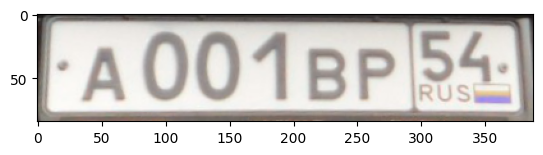

In [ ]:


img_test = cv2.imread(img_path)

plt.imshow(img_test)
print(result[0][1])
plt.show()

## End-to-end detector + CRNN inference

????????? ??????????????? ???????? ??????? ? `crnn_plate_pipeline.py`: ???????? ????? `best.pt`, crop ?????????? ? CRNN, ????????? ??????????? ? `artifacts/pipeline_last_result.json`.


In [ ]:
!python crnn_plate_pipeline.py --mode smoke
# ????? ???????? CRNN:
# !python crnn_plate_pipeline.py --mode pipeline --image data_car_number_labels/images/test/6.jpg --conf 0.01
